# Data Wrangling

What is the purpose of data wrangling?
- Combine datasets that augment our view of the data
- Look at the data from a different perspective

This is one of the big skills of a Data Scientist  
Topics we'll address
- Concatenating
- Mapping
- Encoding
- Joining
- Reshaping

## Maping
Associate one category with another

In [2]:
import numpy as np
import pandas as pd

path = "./Datasets/Gradebook.xlsx"
students = pd.read_excel(path, sheet_name="Students")
assignments = pd.read_excel(path, sheet_name="Assignments")
grades = pd.read_excel(path, sheet_name="Grades")

print(students.shape)
students.head()


(50, 10)


,student_id,first_name,last_name,class_year,gpa,major,first_time_student,financial_aid,housing_status,credits_completed
0,1001,Sarah,Jensen,Sophomore,2.87,History,Yes,Yes,On-Campus,79
1,1002,Marcus,Lee,Junior,3.63,Physics,No,Yes,Off-Campus,83
2,1003,Emily,Torres,Junior,3.27,Biology,No,Yes,Off-Campus,51
3,1004,Daniel,Wright,Junior,2.85,English,Yes,No,On-Campus,58
4,1005,Olivia,Patel,Sophomore,3.21,Business,No,Yes,Off-Campus,26


In [3]:
print(assignments.shape)
assignments.head()

(23, 3)


,assignment_id,assignment_name,category
0,A1,Homework 1,Homework
1,A2,Homework 2,Homework
2,A3,Homework 3,Homework
3,A4,Homework 4,Homework
4,A5,Homework 5,Homework


In [4]:
print(grades.shape)
grades.head()

(1150, 3)


,student_id,assignment_id,grade
0,1001,A1,100
1,1035,A1,100
2,1002,A1,99
3,1030,A1,98
4,1021,A1,97


In [10]:
assignment_map = pd.Series(assignments['category'].values, index=assignments['assignment_id'].to_dict())
assignment_map

0             Homework
1             Homework
2             Homework
3             Homework
4             Homework
5             Homework
6             Homework
7             Homework
8             Homework
9             Homework
10            Homework
11            Homework
12            Homework
13            Homework
14            Homework
15    Computer Project
16    Computer Project
17    Computer Project
18    Computer Project
19    Computer Project
20    Computer Project
21                Exam
22                Exam
dtype: object

## Concatenate data
Let's say we have 3 new students join the class. We need to add their data

In [11]:
students.head()

,student_id,first_name,last_name,class_year,gpa,major,first_time_student,financial_aid,housing_status,credits_completed
0,1001,Sarah,Jensen,Sophomore,2.87,History,Yes,Yes,On-Campus,79
1,1002,Marcus,Lee,Junior,3.63,Physics,No,Yes,Off-Campus,83
2,1003,Emily,Torres,Junior,3.27,Biology,No,Yes,Off-Campus,51
3,1004,Daniel,Wright,Junior,2.85,English,Yes,No,On-Campus,58
4,1005,Olivia,Patel,Sophomore,3.21,Business,No,Yes,Off-Campus,26


In [ ]:
new_students = pd.DataFrame(('student_id': [1101, 1102, 1103],
                             'first_name' : ['John', 'Jack', 'Jill'],
                             ))

In [ ]:
pd.concat([students, new_students], axis=0)

What if I want a new column that indicates the segment of the course each assignment is given in?

In [13]:
assignments

,assignment_id,assignment_name,category
0,A1,Homework 1,Homework
1,A2,Homework 2,Homework
2,A3,Homework 3,Homework
3,A4,Homework 4,Homework
4,A5,Homework 5,Homework
5,A6,Homework 6,Homework
6,A7,Homework 7,Homework
7,A8,Homework 8,Homework
8,A9,Homework 9,Homework
9,A10,Homework 10,Homework


In [14]:
segments = pd.Series([1,1,1,2,2,2,2,3,3,3,3,4,4,4,4,1,1,2,3,3,4,2,4])
pd.concat([assignments, segments], axis=1)

,assignment_id,assignment_name,category,0
0,A1,Homework 1,Homework,1
1,A2,Homework 2,Homework,1
2,A3,Homework 3,Homework,1
3,A4,Homework 4,Homework,2
4,A5,Homework 5,Homework,2
5,A6,Homework 6,Homework,2
6,A7,Homework 7,Homework,2
7,A8,Homework 8,Homework,3
8,A9,Homework 9,Homework,3
9,A10,Homework 10,Homework,3


## Encoding
Numerically represent the categorical variables. We have two types of categorical variables
- Nominal
- Ordinal (meaningful order)
    - Assign a numerical value to each category

In [15]:
students.head()

,student_id,first_name,last_name,class_year,gpa,major,first_time_student,financial_aid,housing_status,credits_completed
0,1001,Sarah,Jensen,Sophomore,2.87,History,Yes,Yes,On-Campus,79
1,1002,Marcus,Lee,Junior,3.63,Physics,No,Yes,Off-Campus,83
2,1003,Emily,Torres,Junior,3.27,Biology,No,Yes,Off-Campus,51
3,1004,Daniel,Wright,Junior,2.85,English,Yes,No,On-Campus,58
4,1005,Olivia,Patel,Sophomore,3.21,Business,No,Yes,Off-Campus,26


In [18]:
classes = {
    'Freshmen' : 1,
    'Sophomore' : 2,
    'Junior' : 3,
    'Senior' : 4
}

students['class'] = students['class_year'].map(classes)

In [19]:
students.head()

,student_id,first_name,last_name,class_year,gpa,major,first_time_student,financial_aid,housing_status,credits_completed,class
0,1001,Sarah,Jensen,Sophomore,2.87,History,Yes,Yes,On-Campus,79,2.0
1,1002,Marcus,Lee,Junior,3.63,Physics,No,Yes,Off-Campus,83,3.0
2,1003,Emily,Torres,Junior,3.27,Biology,No,Yes,Off-Campus,51,3.0
3,1004,Daniel,Wright,Junior,2.85,English,Yes,No,On-Campus,58,3.0
4,1005,Olivia,Patel,Sophomore,3.21,Business,No,Yes,Off-Campus,26,2.0


__One-Hot Encoding__ - Each category is given a column, and the value in that column is 1 if the observation is in that category and 0 if it is not.

In pandas, we use the `pd.get_dumies()` method

In [ ]:
major_dumies = pd.get_dummies(students['major']).astype(int)
# astype(int) changes true and false to 1 and 0's
major_dumies

,Biology,Business,Chemistry,Computer Science,Engineering,English,History,Mathematics,Physics,Psychology,Sociology,Statistics
0,0,0,0,0,0,0,1,0,0,0,0,0
1,0,0,0,0,0,0,0,0,1,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,0,0,0,0,0,0
4,0,1,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,1,0,0,0,0,0
6,0,0,0,0,1,0,0,0,0,0,0,0
7,0,0,1,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,0,0,0,0,0


In [24]:
students = pd.concat([students, major_dumies], axis=1)
students = students.drop(columns=['major'])
students.head()

,student_id,first_name,last_name,class_year,gpa,first_time_student,financial_aid,housing_status,credits_completed,class,...,Chemistry,Computer Science,Engineering,English,History,Mathematics,Physics,Psychology,Sociology,Statistics
0,1001,Sarah,Jensen,Sophomore,2.87,Yes,Yes,On-Campus,79,2.0,...,0,0,0,0,1,0,0,0,0,0
1,1002,Marcus,Lee,Junior,3.63,No,Yes,Off-Campus,83,3.0,...,0,0,0,0,0,0,1,0,0,0
2,1003,Emily,Torres,Junior,3.27,No,Yes,Off-Campus,51,3.0,...,0,0,0,0,0,0,0,0,0,0
3,1004,Daniel,Wright,Junior,2.85,Yes,No,On-Campus,58,3.0,...,0,0,0,1,0,0,0,0,0,0
4,1005,Olivia,Patel,Sophomore,3.21,No,Yes,Off-Campus,26,2.0,...,0,0,0,0,0,0,0,0,0,0


## Joins
A join is where you pair observations from one table with observations from another table

In [3]:
import numpy as np
import pandas as pd

depts = pd.DataFrame({
    'dept_id' : [10, 20, 30, 40],
    'dept_name' : ['Engineering', 'Sales', 'Markerting', 'HR']
})

display(depts)

employees = pd.DataFrame({
    'emp_id' : [1, 2, 3, 4, 5],
    'emp_name' : ['Alice', 'Bob', 'Carol', 'Dan', 'Eve'],
    'dept_id' : [10, 20, 20, 50, pd.NA]
})

display(employees)

,dept_id,dept_name
0,10,Engineering
1,20,Sales
2,30,Markerting
3,40,HR


,emp_id,emp_name,dept_id
0,1,Alice,10
1,2,Bob,20
2,3,Carol,20
3,4,Dan,50
4,5,Eve,<NA>


### Left Join
Take all the entries for the first table. If there are matches in the second table, it includes that data in another column. If there isn't data, it leaves it as NaN.

In [4]:
pd.merge(employees, depts, on='dept_id', how='left')

,emp_id,emp_name,dept_id,dept_name
0,1,Alice,10,Engineering
1,2,Bob,20,Sales
2,3,Carol,20,Sales
3,4,Dan,50,NaN
4,5,Eve,<NA>,NaN


### Right Join
Take all the entries for the second table. If there are matches in the first table, it includes that data in another column. If there isn't data, it leaves it as NaN.

In [5]:
pd.merge(employees, depts, on='dept_id', how='right')

,emp_id,emp_name,dept_id,dept_name
0,1.0,Alice,10,Engineering
1,2.0,Bob,20,Sales
2,3.0,Carol,20,Sales
3,NaN,NaN,30,Markerting
4,NaN,NaN,40,HR


### Inner Join
Takes all the entries that match in both tables

In [6]:
pd.merge(employees, depts, on='dept_id', how='inner')

,emp_id,emp_name,dept_id,dept_name
0,1,Alice,10,Engineering
1,2,Bob,20,Sales
2,3,Carol,20,Sales


### Outer Join
Takes all entries for both tables. Any missing values are marked as NaN

In [7]:
pd.merge(employees, depts, on='dept_id', how='outer')

,emp_id,emp_name,dept_id,dept_name
0,1.0,Alice,10,Engineering
1,2.0,Bob,20,Sales
2,3.0,Carol,20,Sales
3,NaN,NaN,30,Markerting
4,NaN,NaN,40,HR
5,4.0,Dan,50,NaN
6,5.0,Eve,<NA>,NaN


In [15]:
import numpy as np
import pandas as pd

depts = pd.DataFrame({
    'id' : [10, 20, 30, 40],
    'dept_name' : ['Engineering', 'Sales', 'Markerting', 'HR']
})

display(depts)

employees = pd.DataFrame({
    'id' : [1, 2, 3, 4, 5],
    'emp_name' : ['Alice', 'Bob', 'Carol', 'Dan', 'Eve'],
    'department' : [10, 20, 20, 50, pd.NA]
})

display(employees)

,id,dept_name
0,10,Engineering
1,20,Sales
2,30,Markerting
3,40,HR


,id,emp_name,department
0,1,Alice,10
1,2,Bob,20
2,3,Carol,20
3,4,Dan,50
4,5,Eve,<NA>


In [ ]:
pd.merge(employees, 
         depts, 
         left_on='department',
         right_on='id', 
         how='inner',
         suffixes=('_emp', '_dept'))

,id_emp,emp_name,department,id_dept,dept_name
0,1,Alice,10,10,Engineering
1,2,Bob,20,20,Sales
2,3,Carol,20,20,Sales


## Reshaping the data
**Long Format** has each observation in a single row  
**Wide Format** has variables represented by its own column and values filling in those columns (like a table)

In [ ]:
import numpy as np
import pandas as pd

path = "./Datasets/Gradebook.xlsx"
grades = pd.read_excel(path, sheet_name="Grades")

grades.head()

# This is a long format


,student_id,assignment_id,grade
0,1001,A1,100
1,1035,A1,100
2,1002,A1,99
3,1030,A1,98
4,1021,A1,97


In order to shift from Long to Wide format, we need to discuss aggregation.  

### Aggregation
We are taking multiple values that meet the same criteria and finding the best way to represent that data.  
Common aggregation functions inclue  
```python
agg.('max')
agg.('min')
agg.('mean') # Default
agg.('median')
agg.('std')
agg.('count')
```
We can create our own aggregate functions
```python
def range(x):
    return x.max() - x.min()

agg.(range)
```

## Pivot Tables
(Long to Wide Format)  
Take one variable in your observations to be the row of a table. Take another variable to be the column, and a third variable to be the value in the table.

In [20]:
grades.head()

,student_id,assignment_id,grade
0,1001,A1,100
1,1035,A1,100
2,1002,A1,99
3,1030,A1,98
4,1021,A1,97


In [24]:
grade_table = pd.pivot_table(grades,
                             index='student_id',
                             columns='assignment_id',
                             values='grade',
                             aggfunc='max')
display(grade_table)

assignment_id,A1,A10,A11,A12,A13,A14,A15,A2,A3,A4,...,A8,A9,E1,E2,P1,P2,P3,P4,P5,P6
student_id,,,,,,,,,,,,,,,,,,,,,
1001,100,69,99,79,78,95,65,70,60,95,...,70,62,91,88,67,80,93,77,66,82
1002,99,63,71,97,87,93,63,71,66,87,...,97,93,79,60,74,83,90,73,65,84
1003,70,62,75,95,65,73,82,74,89,60,...,76,76,82,69,83,96,80,99,73,77
1004,68,72,60,76,81,73,91,81,68,74,...,68,75,63,92,72,69,80,70,89,95
1005,94,85,77,95,81,72,100,91,95,97,...,64,61,67,79,87,90,96,80,66,69
1006,75,88,75,78,88,63,98,65,79,62,...,70,99,69,81,71,63,98,95,86,75
1007,77,76,97,92,92,91,94,78,68,65,...,90,87,96,63,71,70,65,87,64,96
1008,79,100,77,100,87,62,79,91,98,100,...,66,73,86,90,66,97,97,84,79,83
1009,78,68,90,87,64,85,67,76,74,95,...,89,99,69,67,95,78,77,72,73,75


<Axes: xlabel='assignment_id', ylabel='student_id'>

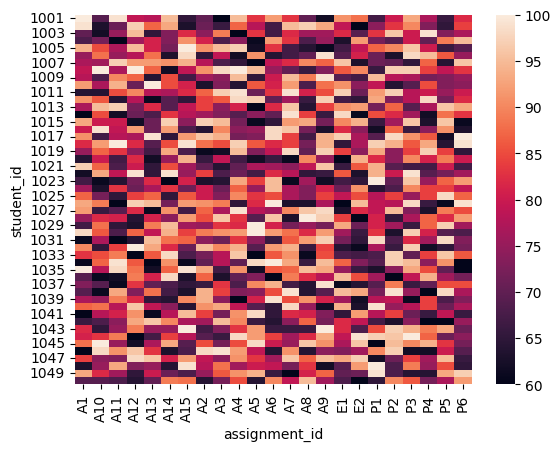

In [23]:
import seaborn as sns
sns.heatmap(grade_table)

## Melting
(Wide to Long Format)  
Does the reverse of Pivot Tables  
- Does not account for aggregated data

In [25]:
pd.melt(grade_table)

,assignment_id,value
0,A1,100
1,A1,99
2,A1,70
3,A1,68
4,A1,94
...,...,...
1145,P6,69
1146,P6,66
1147,P6,65
1148,P6,97


## Groupby

In [ ]:
import numpy as np
import pandas as pd

path = "./Datasets/Gradebook.xlsx"
students = pd.read_excel(path, sheet_name="Students")
students.head()
